In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.decomposition import PCA

In [26]:
rnaseq = pd.read_csv('Datasets/HiSeqV2', sep='\t', index_col=0)
rnaseq = rnaseq.T

clinical = pd.read_csv('Datasets/TCGA.BRCA.sampleMap_BRCA_clinicalMatrix', sep='\t')
clinical['label'] = clinical['sample_type'].apply(lambda x: 1 if 'Tumor' in str(x) else 0)

rnaseq.index.name = 'sampleID'
merged = rnaseq.merge(clinical[['sampleID', 'label']], left_index=True, right_on='sampleID')

print('Merged shape:', merged.shape)
X = merged.drop(['sampleID', 'label'], axis=1).values
y = merged['label'].values
print('Label distribution:', dict(zip(*np.unique(y, return_counts=True))))

Merged shape: (1218, 20532)
Label distribution: {np.int64(0): np.int64(121), np.int64(1): np.int64(1097)}


In [29]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train_raw.shape}\nTest: {X_test_raw.shape}')

Train: (974, 20530)
Test: (244, 20530)


In [28]:
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train_raw)
X_test_imp  = imputer.transform(X_test_raw)

In [30]:
selector = SelectKBest(f_classif, k=100)
X_train_sel = selector.fit_transform(X_train_imp, y_train)
X_test_sel  = selector.transform(X_test_imp)

print(f'Train selected: {X_train_sel.shape}\nTest selected: {X_test_sel.shape}')

Train selected: (974, 100)
Test selected: (244, 100)


c:\Users\shaha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [  144   283   284   297   321   365   565   732   819   824   825   839
  1077  1100  1188  1255  1256  1259  1338  1363  1364  1367  1399  1425
  1430  1461  1619  1655  1743  1766  1891  1993  1994  2003  2031  2032
  2224  2225  2231  2236  2248  2476  2691  2693  2698  2699  2733  2889
  2903  3039  3048  3049  3076  3079  3273  3284  3288  3425  3463  3895
  3994  4036  4050  4051  4052  4135  4933  5009  5033  5242  5299  5371
  5418  5439  5606  5607  5609  5648  5755  6030  6049  6051  6118  6125
  6147  6323  6324  6825  6852  6855  6856  7207  7218  7357  7403  7420
  7421  7440  7602  7800  7857  7858  8000  8025  8107  8276  8565  9029
  9200  9305  9485  9621  9625  9666  9755 10262 10315 10458 10464 10502
 10527 10528 10565 10585 10605 10608 10668 10689 10690 10899 10958 10959
 10962 10963 10964 10965 10966 10996 10999 111

In [31]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_sel, y_train)
    preds = model.predict(X_test_sel)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f'\n── {name} ──')
    print(classification_report(y_test, preds, target_names=['Normal', 'Tumor']))

print('\nFinal accuracies:', results)


── Random Forest ──
              precision    recall  f1-score   support

      Normal       1.00      0.79      0.88        24
       Tumor       0.98      1.00      0.99       220

    accuracy                           0.98       244
   macro avg       0.99      0.90      0.94       244
weighted avg       0.98      0.98      0.98       244


── SVM ──
              precision    recall  f1-score   support

      Normal       1.00      0.83      0.91        24
       Tumor       0.98      1.00      0.99       220

    accuracy                           0.98       244
   macro avg       0.99      0.92      0.95       244
weighted avg       0.98      0.98      0.98       244


── Logistic Regression ──
              precision    recall  f1-score   support

      Normal       1.00      0.88      0.93        24
       Tumor       0.99      1.00      0.99       220

    accuracy                           0.99       244
   macro avg       0.99      0.94      0.96       244
weighted avg   

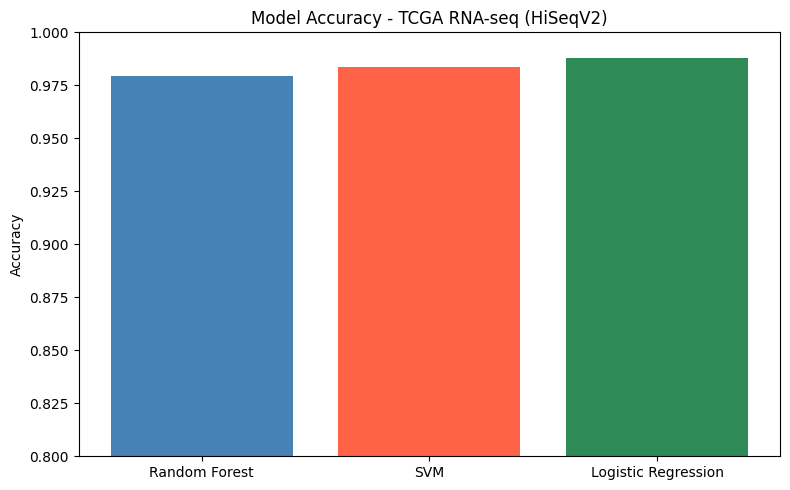

In [36]:
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values(), color=['steelblue', 'tomato', 'seagreen'])
plt.title('Model Accuracy - TCGA RNA-seq (HiSeqV2)')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.0)
plt.tight_layout()
plt.savefig('rnaseq_accuracy.png', dpi=150)
plt.show()

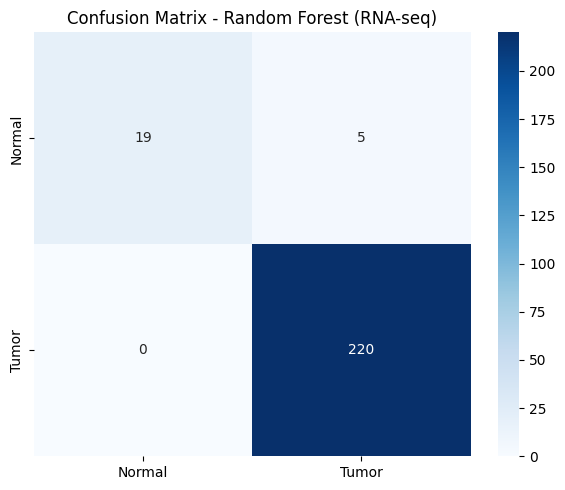

In [ ]:
rf_preds = models['Random Forest'].predict(X_test_sel)
cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Tumor'],
            yticklabels=['Normal', 'Tumor'])
plt.title('Confusion Matrix - Random Forest (RNA-seq)')
plt.tight_layout()
plt.savefig('rnaseq_confusion.png', dpi=150)
plt.show()

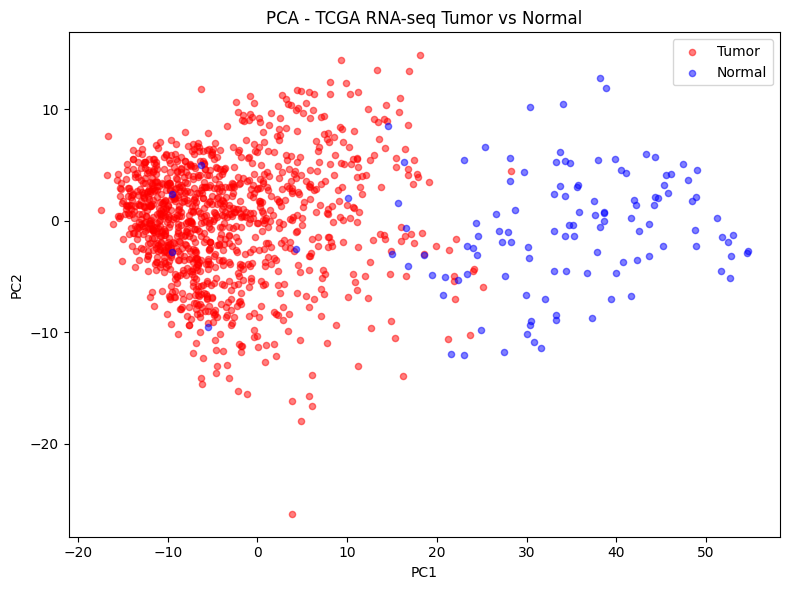

Accuracies: {'Random Forest': 0.9795081967213115, 'SVM': 0.9836065573770492, 'Logistic Regression': 0.9877049180327869}


In [38]:
X_all_imp = imputer.transform(X)
X_all_sel = selector.transform(X_all_imp)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_all_sel)

plt.figure(figsize=(8, 6))
for label, color, name in [(1, 'red', 'Tumor'), (0, 'blue', 'Normal')]:
    idx = y == label
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], c=color, label=name, alpha=0.5, s=20)
plt.title('PCA - TCGA RNA-seq Tumor vs Normal')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.savefig('rnaseq_pca.png', dpi=150)
plt.show()

print('Accuracies:', results)